# Exploring the prices dataset

In [4]:
import pandas as pd 

df = pd.read_csv("wfp_food_prices_uga.csv")
df.shape


(25526, 16)

In [5]:
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Busia,Samia-bugwe,Busia,2665,0.47,34.09,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,298.40,0.17
1,2006-01-15,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Rice,52,KG,actual,Wholesale,UGX,1013.40,0.58
2,2006-01-15,Lira,Lira Municipality,Lira,263,2.23,32.91,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,247.76,0.14
3,2006-02-15,Busia,Samia-bugwe,Busia,2665,0.47,34.09,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,296.59,0.17
4,2006-02-15,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,347.23,0.20


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25526 entries, 0 to 25525
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          25526 non-null  str    
 1   admin1        25526 non-null  str    
 2   admin2        25526 non-null  str    
 3   market        25526 non-null  str    
 4   market_id     25526 non-null  int64  
 5   latitude      25526 non-null  float64
 6   longitude     25526 non-null  float64
 7   category      25526 non-null  str    
 8   commodity     25526 non-null  str    
 9   commodity_id  25526 non-null  int64  
 10  unit          25526 non-null  str    
 11  priceflag     25526 non-null  str    
 12  pricetype     25526 non-null  str    
 13  currency      25526 non-null  str    
 14  price         25526 non-null  float64
 15  usdprice      25526 non-null  float64
dtypes: float64(4), int64(2), str(10)
memory usage: 3.1 MB


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("All imports OK")


All imports OK


## What we're building

A **supervised regression** model that predicts `price` (UGX/kg) for the *next* month.

**Key terms:**
- **Supervised learning** — we train on examples where we already know the answer (historical prices)
- **Regression** — the output is a continuous number (price), not a category
- **Target variable** — `price` shifted one month forward (what the model must predict)
- **Features** — everything the model sees as input: past prices, rolling averages, month, year


In [7]:
maize_df = df[df["commodity"] == "Maize"].copy()

print("=== Maize rows per market ===")
print(maize_df.groupby("market")["price"].agg(["count", "min", "max", "mean"]).round(0))


=== Maize rows per market ===
         count    min     max   mean
market                              
Busia      103  256.0  1675.0  701.0
Kabale      29  541.0  1366.0  925.0
Lira       183  248.0  1531.0  747.0
Masindi     32  510.0  1124.0  823.0
Owino      202  204.0  1655.0  793.0


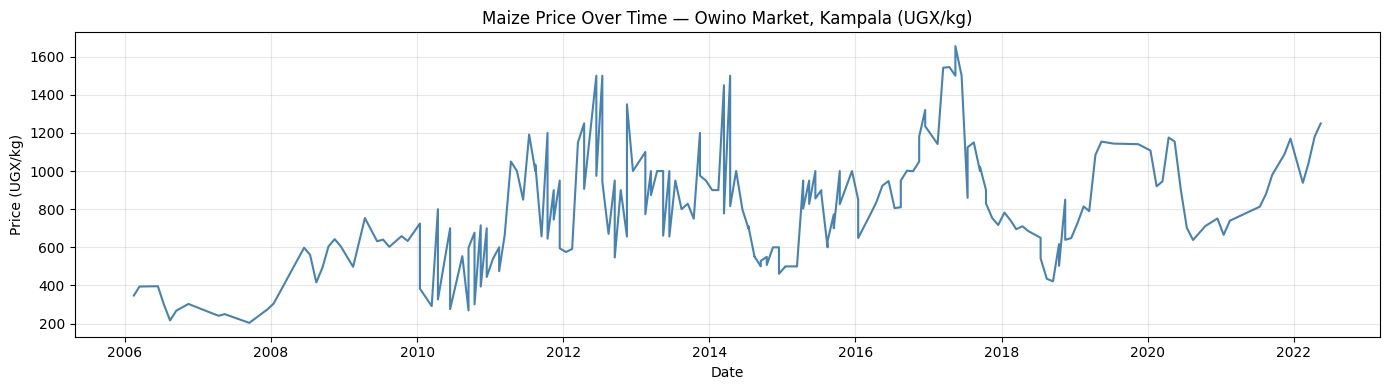

Rows: 202
Date range: 2006-02-15 to 2022-05-15


In [8]:
owino = maize_df[maize_df["market"] == "Owino"].copy()
owino["date"] = pd.to_datetime(owino["date"])
owino = owino.sort_values("date")

plt.figure(figsize=(14, 4))
plt.plot(owino["date"], owino["price"], color="steelblue", linewidth=1.5)
plt.title("Maize Price Over Time — Owino Market, Kampala (UGX/kg)")
plt.xlabel("Date")
plt.ylabel("Price (UGX/kg)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rows: {len(owino)}")
print(f"Date range: {owino['date'].min().date()} to {owino['date'].max().date()}")


## What the chart tells us

The price is not random — it has structure:
- **Trend** — prices generally rise over time (inflation, population growth)
- **Seasonality** — prices drop after harvest (Oct–Jan) and climb before harvest (Mar–Jul)
- **Noise** — random variation the model won't capture (droughts, border closures, COVID)

This is why our features will include **month** (captures seasonality) and **year** (captures trend).


In [11]:
owino_sorted = owino.set_index("date").sort_index()
expected_months = pd.date_range(
    start=owino_sorted.index.min(),
    end=owino_sorted.index.max(),
    freq="MS"
)
actual_months = owino_sorted.index.to_period("M").to_timestamp()
missing = expected_months[~expected_months.isin(actual_months)]
print(f"Missing months: {len(missing)}")
if len(missing) > 0:
    print(missing.tolist())


Missing months: 42
[Timestamp('2006-04-01 00:00:00'), Timestamp('2006-05-01 00:00:00'), Timestamp('2006-10-01 00:00:00'), Timestamp('2006-12-01 00:00:00'), Timestamp('2007-01-01 00:00:00'), Timestamp('2007-02-01 00:00:00'), Timestamp('2007-06-01 00:00:00'), Timestamp('2007-07-01 00:00:00'), Timestamp('2007-10-01 00:00:00'), Timestamp('2007-11-01 00:00:00'), Timestamp('2008-02-01 00:00:00'), Timestamp('2008-03-01 00:00:00'), Timestamp('2008-04-01 00:00:00'), Timestamp('2008-05-01 00:00:00'), Timestamp('2009-01-01 00:00:00'), Timestamp('2009-03-01 00:00:00'), Timestamp('2009-05-01 00:00:00'), Timestamp('2009-09-01 00:00:00'), Timestamp('2009-12-01 00:00:00'), Timestamp('2010-02-01 00:00:00'), Timestamp('2010-05-01 00:00:00'), Timestamp('2010-07-01 00:00:00'), Timestamp('2012-05-01 00:00:00'), Timestamp('2013-01-01 00:00:00'), Timestamp('2015-02-01 00:00:00'), Timestamp('2015-11-01 00:00:00'), Timestamp('2016-02-01 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2018-06-01 00:00:

## ML Glossary — Terms used in this project

| Term | Plain English |
|------|--------------|
| **Supervised learning** | Training on examples where the answer is known |
| **Regression** | Predicting a number (vs classification = predicting a category) |
| **Feature** | An input column the model uses to make predictions |
| **Target variable** | The column we're trying to predict |
| **Feature engineering** | Creating new features from raw data to help the model |
| **Lag feature** | "What was the value N months ago?" |
| **Rolling mean** | Average over a sliding window of past values |
| **Train/test split** | Dividing data so the model is evaluated on unseen examples |
| **Data leakage** | Accidentally using future data during training — invalidates results |
| **Overfitting** | Model memorises training data, fails to generalise |
| **Random Forest** | An ensemble of 100+ decision trees, averaged for better predictions |
| **Decision tree** | A model that makes predictions by asking yes/no questions |
| **Ensemble** | Combining many models to reduce error |
| **Hyperparameter** | A setting you choose before training (not learned from data) |
| **MAE** | Mean Absolute Error — average absolute difference between predicted and actual |
| **Feature importance** | How much each feature influenced the model's decisions |
